In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

In [17]:
iris = load_iris(as_frame=True).frame
X = iris.drop(columns=["target"])
y = iris["target"]

In [18]:
scaler = StandardScaler().set_output(transform="pandas")
X = scaler.fit_transform(X)

In [27]:
pca = PCA(
    n_components=2,

).set_output(transform="pandas")

X_pca = pca.fit_transform(X)

In [28]:
X_pca.head()

,pca0,pca1
0,-2.264703,0.480027
1,-2.080961,-0.674134
2,-2.364229,-0.341908
3,-2.299384,-0.597395
4,-2.389842,0.646835


In [20]:
print("Variance ratio", pca.explained_variance_ratio_)

Variance ratio [0.72962445 0.22850762]


In [21]:
print(pca.components_)

[[ 0.52106591 -0.26934744  0.5804131   0.56485654]
 [ 0.37741762  0.92329566  0.02449161  0.06694199]]


<Axes: xlabel='pca0', ylabel='pca1'>

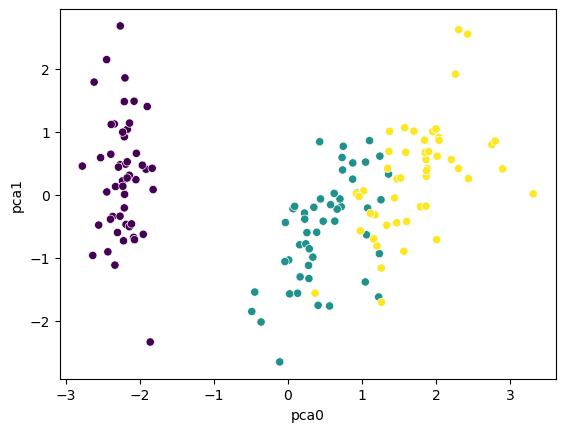

In [29]:
sns.scatterplot(
    x=X_pca.iloc[:, 0],
    y=X_pca.iloc[:, 1],
    c=y
)



In [30]:
km_model = KMeans(
    n_clusters=3
)
labels = km_model.fit_predict(X_pca)

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


<Axes: xlabel='pca0', ylabel='pca1'>

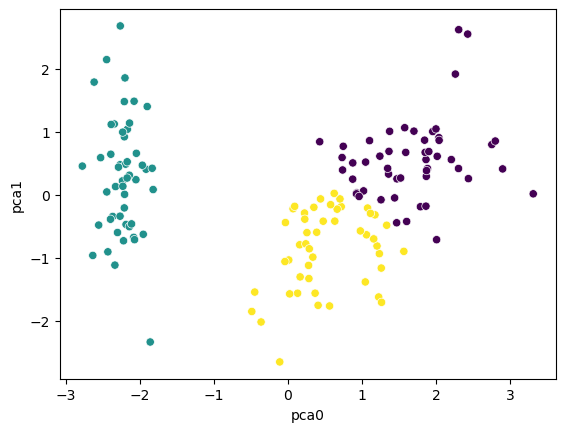

In [31]:
sns.scatterplot(
    x=X_pca.iloc[:, 0],
    y=X_pca.iloc[:, 1],
    c=labels
)

In [34]:
# T SNE
tsne = TSNE(
    n_components=2,
    random_state=42,
)

X_tnse = pd.DataFrame(tsne.fit_transform(X))

In [35]:
X_tnse.head()

,0,1
0,-24.509983,-0.108798
1,-20.713358,0.175788
2,-21.735729,-0.632472
3,-20.963203,-0.580183
4,-25.130976,0.075729


<Axes: xlabel='0', ylabel='1'>

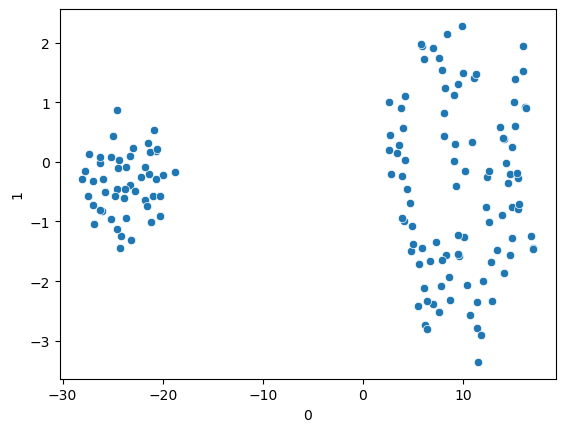

In [38]:
sns.scatterplot(
    x=X_tnse.iloc[:, 0],
    y=X_tnse.iloc[:, 1],
)